In [2]:
!pip install pandas numpy matplotlib xgboost scikit-learn seaborn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 8.2 MB/s eta 0:00:13
   - -------------------------------------- 3.7/101.7 MB 8.5 MB/s eta 0:00:12
   --- ------------------------------------ 8.4/101.7 MB 14.1 MB/s eta 0:00:07
   ---- ----------------------------------- 10.2/101.7 MB 13.6 MB/s eta 0:00:07
   ----- ---------------------------------- 12.8/101.7 MB 13.0 MB/s eta 0:00:07
   ------ --------------------------------- 16.3/101.7 MB 12.9 MB/s eta 0:00:07
   ------- -------------------------------- 18.9/101.7 MB 12.8 MB/s eta 0:00:07
   -------- ------------------------------- 21.2/101.7 MB 12.7 MB/s eta 0:00:07
   -------- ------------------------------- 22.5/101.7 MB 12.7 MB/s eta 0:00:07
   ---------- ----------------------------- 26.2/101.7 MB 12.6 MB/s eta 0:00:06
   ----------- ---------------------------- 28.6/101.7 MB 12.5 

In [41]:
import pandas as pd

y10 = pd.read_excel(r'C:\Users\Sofya\Desktop\проект облигации\rub-yield-curve-10y.xlsx')
y2  = pd.read_excel(r'C:\Users\Sofya\Desktop\проект облигации\rub-yield-curve-2y.xlsx')

print("10Y")
print(y10.shape)
print(y10.columns)
print(y10.head(3))

print("\2Y")
print(y2.shape)
print(y2.columns)
print(y2.head(3))

10Y
(3016, 2)
Index(['Дата', 'RUB Yield Curve 10Y'], dtype='object')
        Дата  RUB Yield Curve 10Y
0 2025-12-30              14.4382
1 2025-12-29              14.3689
2 2025-12-26              14.4372
Y
(3016, 2)
Index(['Дата', 'RUB Yield Curve 2Y'], dtype='object')
        Дата  RUB Yield Curve 2Y
0 2025-12-30             13.9180
1 2025-12-29             14.1762
2 2025-12-26             14.3420


In [42]:
import pandas as pd
import os
path = r'C:\Users\Sofya\Desktop\проект облигации' + '\\'
y10 = pd.read_excel(path + 'rub-yield-curve-10y.xlsx')
y2  = pd.read_excel(path + 'rub-yield-curve-2y.xlsx')

y10['Дата'] = pd.to_datetime(y10['Дата'])
y2['Дата']  = pd.to_datetime(y2['Дата'])
y10 = y10.set_index('Дата')
y2  = y2.set_index('Дата')

y10.columns = ['ofz_10y']
y2.columns  = ['ofz_2y']

y10_m = y10.resample('ME').last()
y2_m  = y2.resample('ME').last()

gcurve = pd.concat([y10_m, y2_m], axis=1)
gcurve['spread_10y_2y'] = gcurve['ofz_10y'] - gcurve['ofz_2y']
gcurve = gcurve.loc['2014-01':'2025-12']

print("Кривая ОФЗ")
print(gcurve.shape)
print(gcurve.head(3))
print(gcurve.isnull().sum())

Кривая ОФЗ
(144, 3)
            ofz_10y  ofz_2y  spread_10y_2y
Дата                                      
2014-01-31   8.5363  6.9339         1.6024
2014-02-28   8.4735  6.9986         1.4749
2014-03-31   8.9195  7.8384         1.0811
ofz_10y          0
ofz_2y           0
spread_10y_2y    0
dtype: int64


In [16]:
df_macro = pd.read_excel(path + 'Инфляция и ключевая ставка.xlsx', 
                          sheet_name='Инфляция и ключевая ставка Банк')
print(df_macro.shape)
print(df_macro.columns.tolist())
print(df_macro.head(5))

(144, 3)
['Дата', 'Ключевая ставка, % годовых', 'Инфляция, % г/г']
      Дата  Ключевая ставка, % годовых  Инфляция, % г/г
0  12.2025                        16.0             5.59
1  11.2025                        16.5             6.64
2  10.2025                        16.5             7.71
3   9.2025                        17.0             7.98
4   8.2025                        18.0             8.14


In [43]:
df_macro = pd.read_excel(path + 'Инфляция и ключевая ставка.xlsx',
                          sheet_name='Инфляция и ключевая ставка Банк')
def parse_date(x):
    s = str(round(x, 4))        
    parts = s.split('.')        
    month = int(parts[0])       
    year  = int(parts[1])      
    return pd.Timestamp(year=year, month=month, day=1)

df_macro['Дата'] = df_macro['Дата'].apply(parse_date)

df_macro = df_macro.set_index('Дата')
df_macro.index = df_macro.index + pd.offsets.MonthEnd(0)

df_macro.columns = ['key_rate', 'cpi_yoy']

df_macro = df_macro.sort_index()

print(df_macro.shape)
print(df_macro.head(3))
print(df_macro.tail(3))
print(df_macro.isnull().sum())

(144, 2)
                     key_rate  cpi_yoy
Дата                                  
0202-01-31 00:00:00      6.25      2.4
0202-02-28 00:00:00      6.00      2.3
0202-03-31 00:00:00      6.00      2.5
                     key_rate  cpi_yoy
Дата                                  
2025-10-31 00:00:00      16.5     7.71
2025-11-30 00:00:00      16.5     6.64
2025-12-31 00:00:00      16.0     5.59
key_rate    0
cpi_yoy     0
dtype: int64


In [46]:
df_macro = pd.read_excel(path + 'Инфляция и ключевая ставка.xlsx',
                          sheet_name='Инфляция и ключевая ставка Банк')

def parse_date(x):
    s = str(round(x, 4))
    parts = s.split('.')
    month = int(parts[0])
    year_str = parts[1]
    
    if len(year_str) == 3:
        year_str = year_str + '0'
    year = int(year_str)
    return pd.Timestamp(year=year, month=month, day=1)

df_macro['Дата'] = df_macro['Дата'].apply(parse_date)

df_macro = df_macro.set_index('Дата')
df_macro.index = df_macro.index + pd.offsets.MonthEnd(0)
df_macro.columns = ['key_rate', 'cpi_yoy']
df_macro = df_macro.sort_index()

print(df_macro.shape)
print(df_macro.head(3))
print(df_macro.loc['2020-01':'2020-12'])
print(df_macro.tail(3))
print(df_macro.isnull().sum())

(144, 2)
            key_rate  cpi_yoy
Дата                         
2014-01-31       5.5     6.07
2014-02-28       5.5     6.21
2014-03-31       7.0     6.92
            key_rate  cpi_yoy
Дата                         
2020-01-31      6.25      2.4
2020-02-29      6.00      2.3
2020-03-31      6.00      2.5
2020-04-30      5.50      3.1
2020-05-31      5.50      3.0
2020-06-30      4.50      3.2
2020-07-31      4.25      3.4
2020-08-31      4.25      3.6
2020-09-30      4.25      3.7
2020-10-31      4.25      4.0
2020-11-30      4.25      4.4
2020-12-31      4.25      4.9
            key_rate  cpi_yoy
Дата                         
2025-10-31      16.5     7.71
2025-11-30      16.5     6.64
2025-12-31      16.0     5.59
key_rate    0
cpi_yoy     0
dtype: int64


In [62]:
#Курс USD/RUB
usd_rub = pd.read_excel(path + 'usd_rub курс.xlsx')
print("USD/RUB")
print(usd_rub.columns.tolist())
print(usd_rub.head(3))

#Нефть
brent = pd.read_excel(path + 'нефть.xlsx')
print("\nНефть")
print(brent.columns.tolist())
print(brent.head(3))

#RGBI
rgbi = pd.read_excel(path + 'rgbi.xlsx')
print("\nRGBI")
print(rgbi.columns.tolist())
print(rgbi.head(3))

#US Treasury 10Y
ust10 = pd.read_excel(path + 'ust-10y-ytm.xlsx')
print("\nUST 10Y")
print(ust10.columns.tolist())
print(ust10.head(3))

#ИПЦ
ipc = pd.read_excel(path + 'ипц.xlsx')
print("\nИПЦ")
print(ipc.columns.tolist())
print(ipc.head(3))

USD/RUB
['Дата', 'USD/RUB (Банк России)']
        Дата  USD/RUB (Банк России)
0 2025-12-31                78.2267
1 2025-12-30                77.4466
2 2025-12-29                77.6923

Нефть
['Дата', 'Нефть Brent']
        Дата  Нефть Brent
0 2025-12-31        60.85
1 2025-12-30        61.33
2 2025-12-29        61.49

RGBI
['Дата', 'RGBI RU000A0JQV61']
        Дата  RGBI RU000A0JQV61
0 2025-12-30             118.08
1 2025-12-29             117.67
2 2025-12-26             117.38

UST 10Y
['Дата', 'UST 10Y YTM']
        Дата  UST 10Y YTM
0 2025-12-31         4.18
1 2025-12-30         4.14
2 2025-12-29         4.12

ИПЦ
['Дата', 'ИПЦ м/м, к концу предыдущего месяца: товары и услуги']
        Дата  ИПЦ м/м, к концу предыдущего месяца: товары и услуги
0 2025-12-31                                             100.32   
1 2025-11-30                                             100.42   
2 2025-10-31                                             100.50   


In [63]:
#USD/RUB
usd_rub['Дата'] = pd.to_datetime(usd_rub['Дата'])
usd_rub = usd_rub.set_index('Дата')
usd_rub.columns = ['usd_rub']
usd_rub_m = usd_rub.resample('ME').last()

#Нефть
brent['Дата'] = pd.to_datetime(brent['Дата'])
brent = brent.set_index('Дата')
brent.columns = ['brent']
brent_m = brent.resample('ME').last()

#RGBI
rgbi['Дата'] = pd.to_datetime(rgbi['Дата'])
rgbi = rgbi.set_index('Дата')
rgbi.columns = ['rgbi']
rgbi_m = rgbi.resample('ME').last()

#UST 10Y
ust10['Дата'] = pd.to_datetime(ust10['Дата'])
ust10 = ust10.set_index('Дата')
ust10.columns = ['ust10y']
ust10_m = ust10.resample('ME').last()

#ИПЦ м/м
ipc['Дата'] = pd.to_datetime(ipc['Дата'])
ipc = ipc.set_index('Дата')
ipc.columns = ['cpi_mom']

ipc['cpi_mom'] = ipc['cpi_mom'] - 100
ipc_m = ipc.resample('ME').last()

df = pd.concat([
    gcurve,        # ofz_10y, ofz_2y, spread_10y_2y
    df_macro,      # key_rate, cpi_yoy
    usd_rub_m,     # usd_rub
    brent_m,       # brent
    rgbi_m,        # rgbi
    ust10_m,       # ust10y
    ipc_m          # cpi_mom
], axis=1)

df = df.loc['2014-01':'2025-12']

#построение регрессии: изменение доходности через 1 месяц
df['target_reg'] = df['ofz_10y'].shift(-1) - df['ofz_10y']

#классификация: направление (1=рост, 0=снижение)
df['target_cls'] = (df['target_reg'] > 0).astype(int)

print("итоговый датафрейм")
print(df.shape)
print(df.columns.tolist())
print(df.head(3))
print(df.tail(3))
print("\nПропуски:")
print(df.isnull().sum())

итоговый датафрейм
(144, 12)
['ofz_10y', 'ofz_2y', 'spread_10y_2y', 'key_rate', 'cpi_yoy', 'usd_rub', 'brent', 'rgbi', 'ust10y', 'cpi_mom', 'target_reg', 'target_cls']
            ofz_10y  ofz_2y  spread_10y_2y  key_rate  cpi_yoy  usd_rub  \
Дата                                                                     
2014-01-31   8.5363  6.9339         1.6024       5.5     6.07  35.2448   
2014-02-28   8.4735  6.9986         1.4749       5.5     6.21  36.0501   
2014-03-31   8.9195  7.8384         1.0811       7.0     6.92  35.6871   

             brent    rgbi  ust10y  cpi_mom  target_reg  target_cls  
Дата                                                                 
2014-01-31  106.40  130.19    2.67     0.59     -0.0628           0  
2014-02-28  109.07  129.87    2.66     0.70      0.4460           1  
2014-03-31  107.76  126.83    2.73     1.02      0.6556           1  
            ofz_10y   ofz_2y  spread_10y_2y  key_rate  cpi_yoy  usd_rub  \
Дата                                

In [49]:
df.to_csv(path + 'dataset_ofz.csv')
print("Датафрейм сохранён")
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} колонок")
print(f"Период: {df.index[0].strftime('%Y-%m')} — {df.index[-1].strftime('%Y-%m')}")

датафрейм сохранён
Размер: 144 строк, 12 колонок
Период: 2014-01 — 2025-12


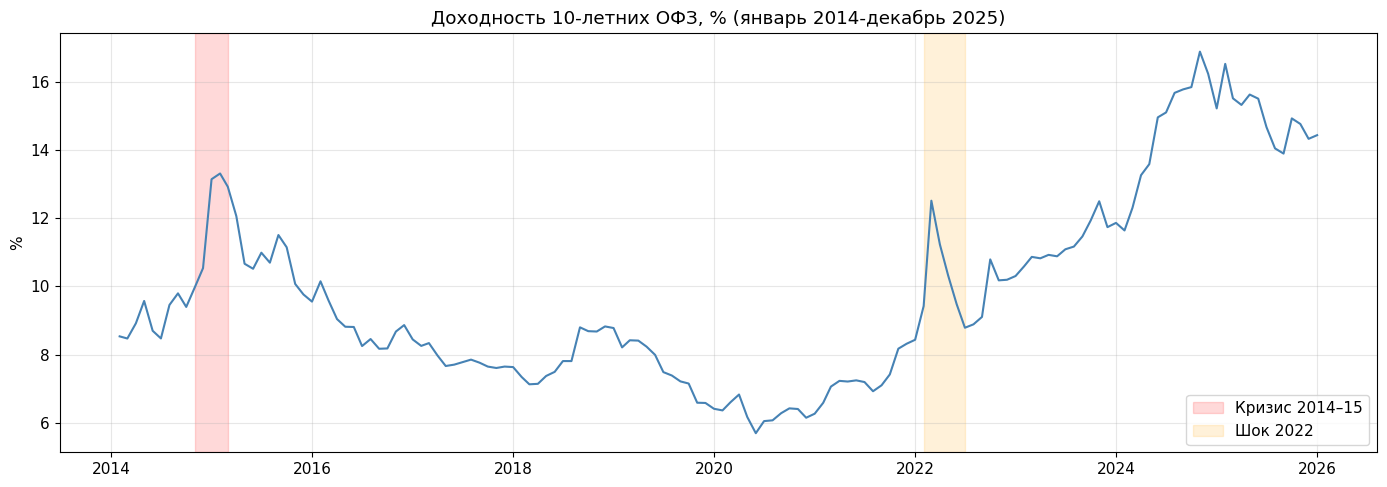

In [53]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

#график 1: Целевая переменная: доходность 10Y ОФЗ
fig, ax = plt.subplots()
ax.plot(df.index, df['ofz_10y'], color='steelblue', linewidth=1.5)
ax.set_title('Доходность 10-летних ОФЗ, % (январь 2014-декабрь 2025)')
ax.set_ylabel('%')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, alpha=0.3)

#кризисные периоды
ax.axvspan('2014-11-01', '2015-02-28', alpha=0.15, color='red', label='Кризис 2014–15')
ax.axvspan('2022-02-01', '2022-06-30', alpha=0.15, color='orange', label='Шок 2022')
ax.legend()
plt.tight_layout()
plt.savefig(path + 'plot_ofz_10y.png', dpi=150)
plt.show()

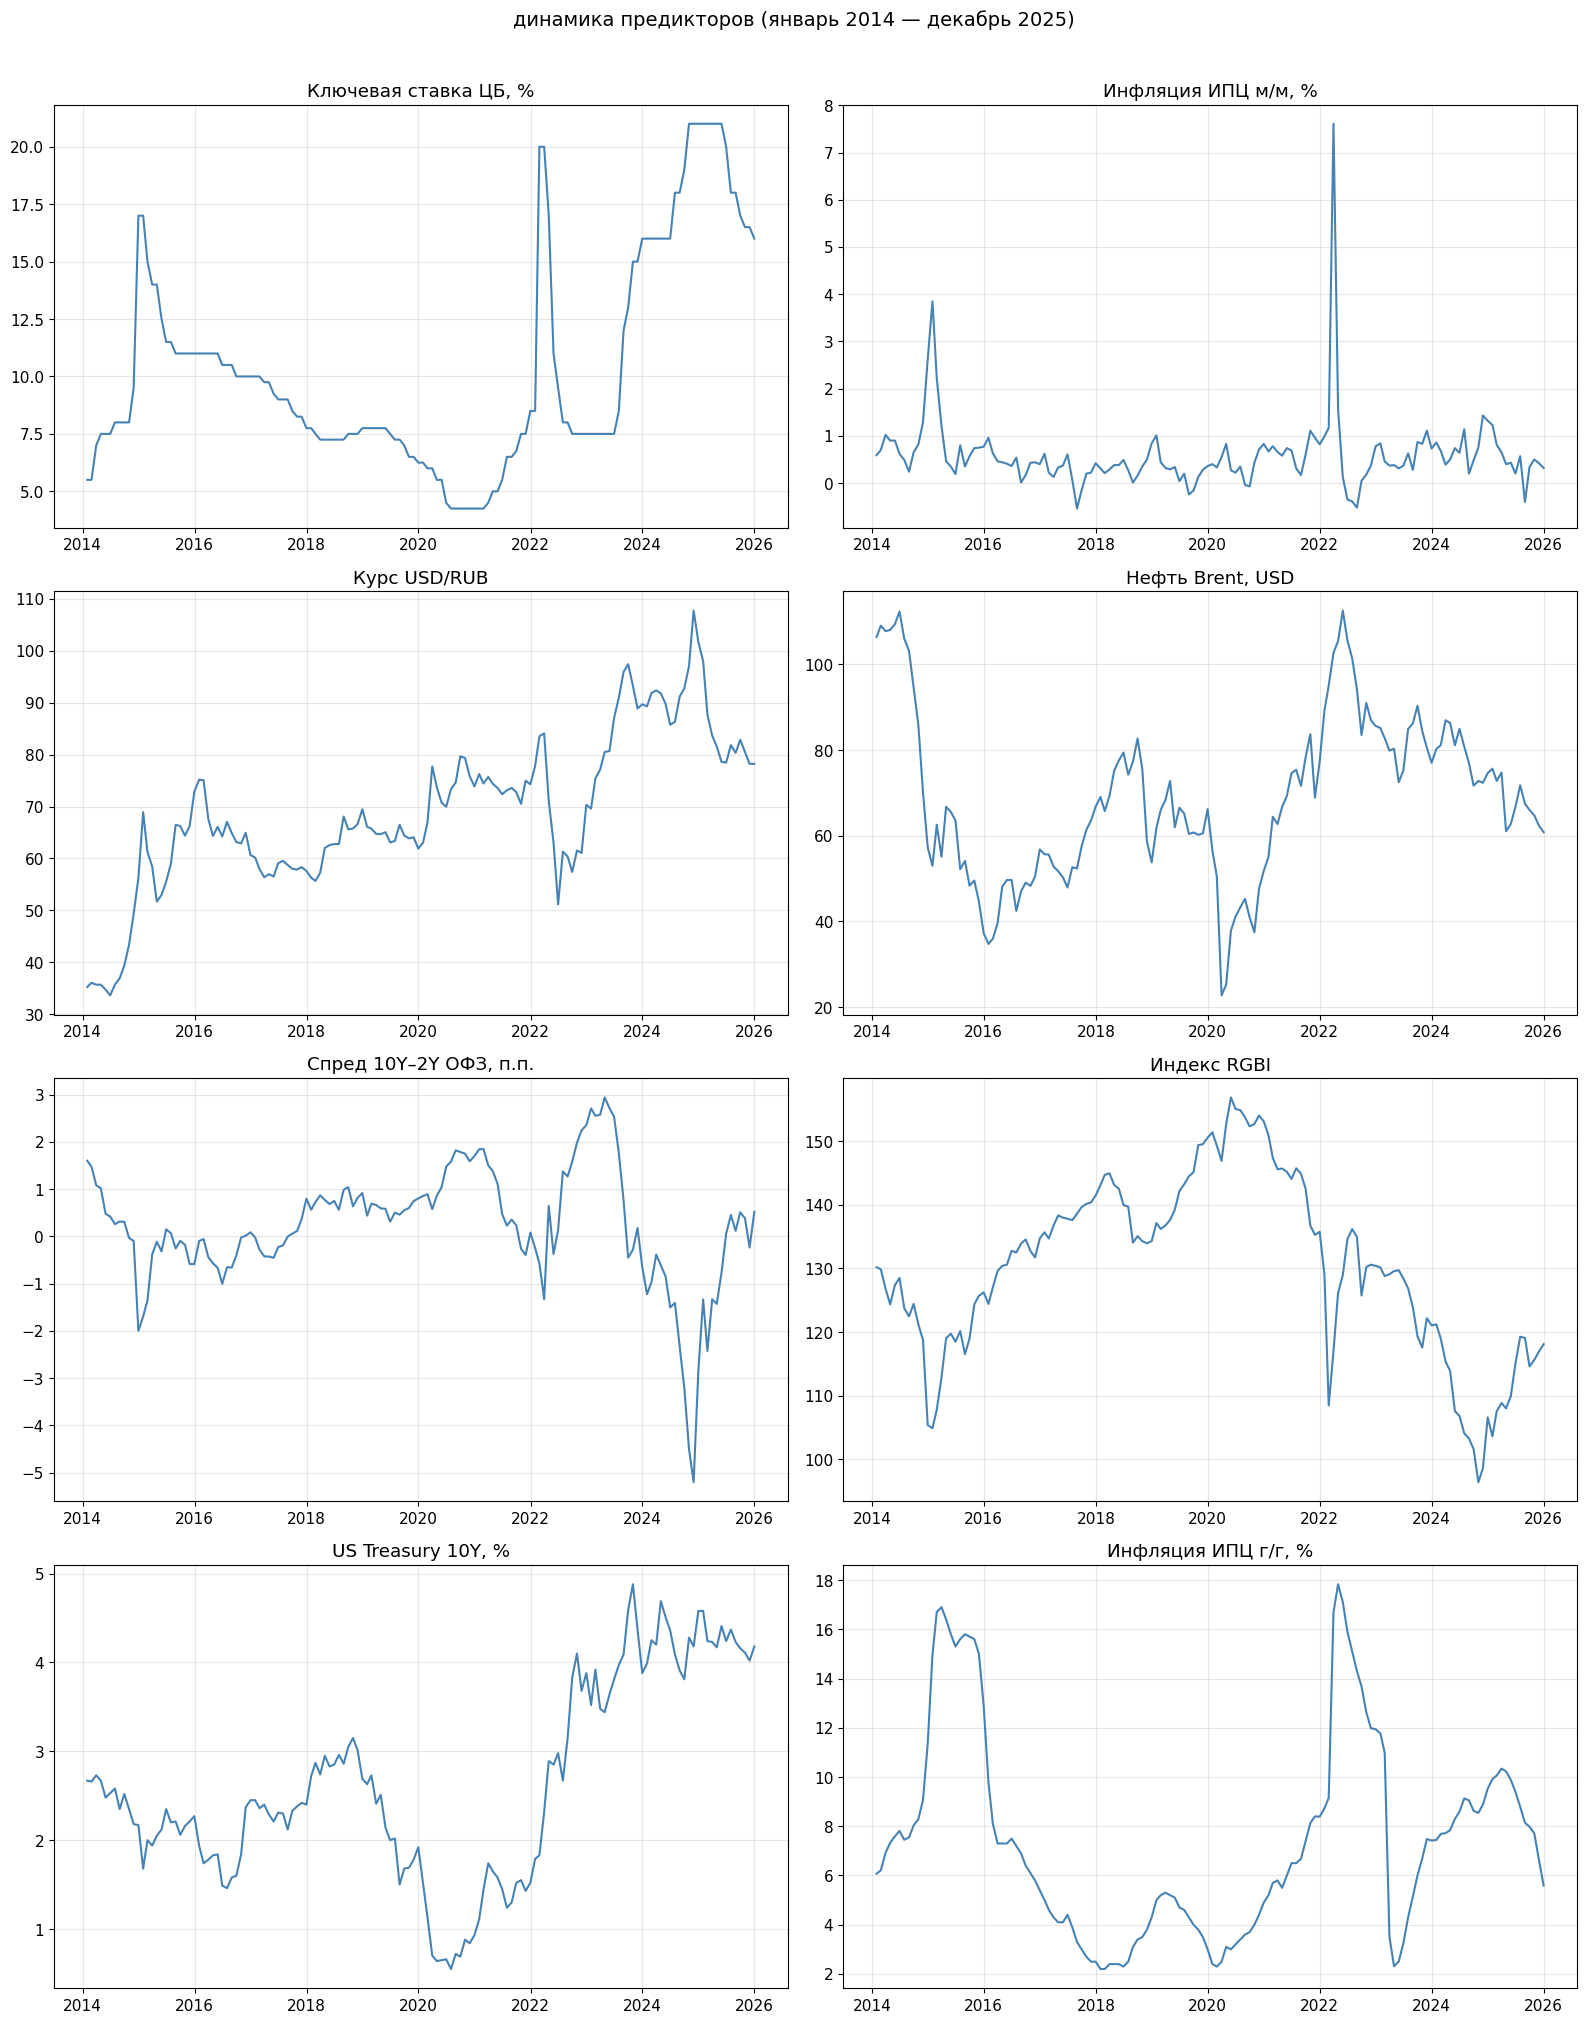

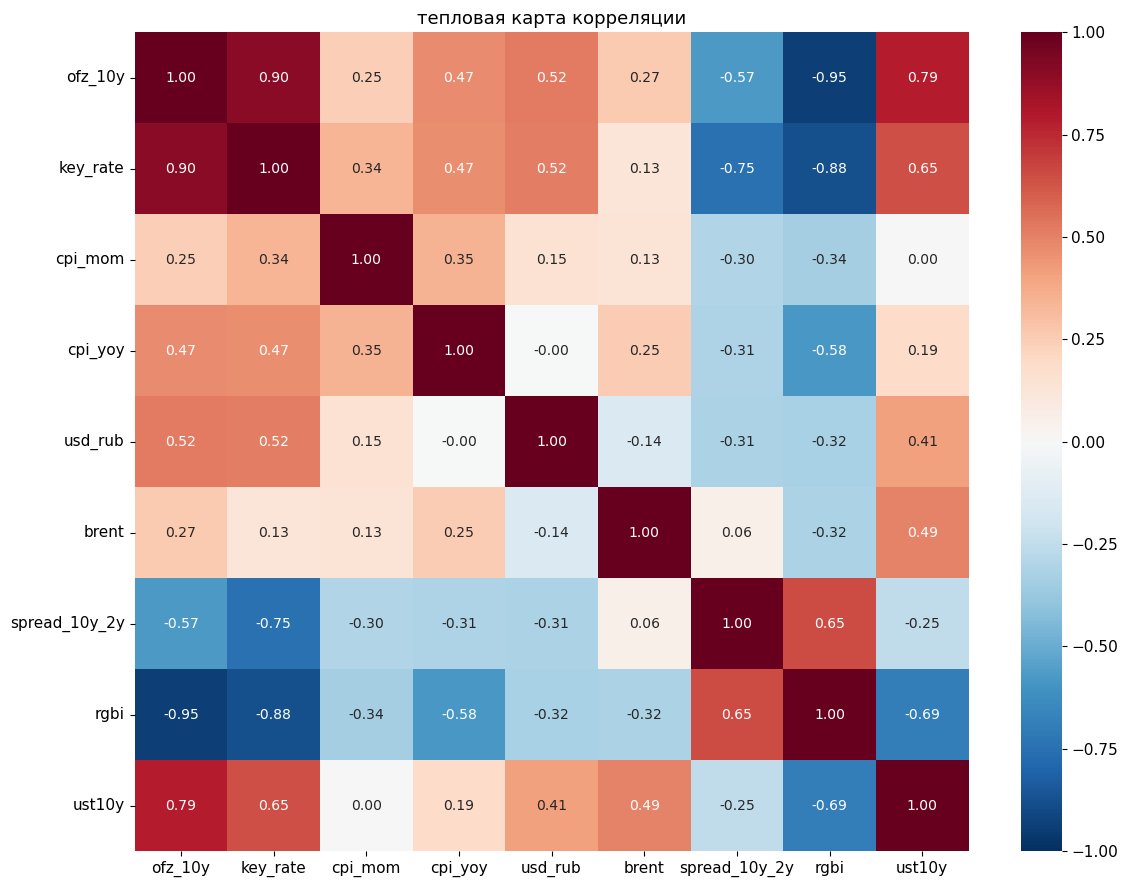

In [51]:
#график 2: все предикторы
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

vars_to_plot = [
    ('key_rate',      'Ключевая ставка ЦБ, %'),
    ('cpi_mom',       'Инфляция ИПЦ м/м, %'),
    ('usd_rub',       'Курс USD/RUB'),
    ('brent',         'Нефть Brent, USD'),
    ('spread_10y_2y', 'Спред 10Y–2Y ОФЗ, п.п.'),
    ('rgbi',          'Индекс RGBI'),
    ('ust10y',        'US Treasury 10Y, %'),
    ('cpi_yoy',       'Инфляция ИПЦ г/г, %'),
]

for i, (col, title) in enumerate(vars_to_plot):
    axes[i].plot(df.index, df[col], linewidth=1.5, color='steelblue')
    axes[i].set_title(title)
    axes[i].grid(True, alpha=0.3)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('динамика предикторов (январь 2014 — декабрь 2025)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(path + 'plot_predictors.png', dpi=150, bbox_inches='tight')
plt.show()

#график 3: тепловая карта корреляции
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 9))

cols_for_corr = ['ofz_10y', 'key_rate', 'cpi_mom', 'cpi_yoy',
                 'usd_rub', 'brent', 'spread_10y_2y', 'rgbi', 'ust10y']

corr = df[cols_for_corr].corr()

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            annot_kws={'size': 10})

ax.set_title('тепловая карта корреляции', fontsize=13)
plt.tight_layout()
plt.savefig(path + 'plot_correlation.png', dpi=150)
plt.show()

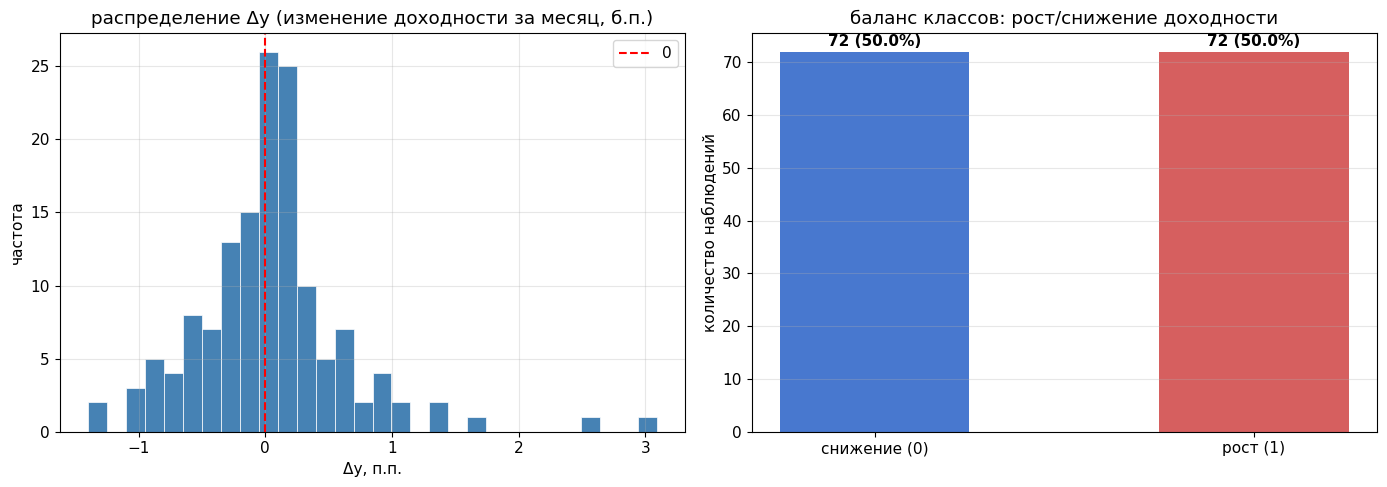


Описательная статистика Δy
count    143.0000
mean       0.0413
std        0.6082
min       -1.3983
25%       -0.2487
50%        0.0093
75%        0.2351
max        3.0914
Name: target_reg, dtype: float64

доля месяцев с ростом доходности: 50.0%


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#график слева: распределение изменений доходности
axes[0].hist(df['target_reg'].dropna(), bins=30, 
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='0')
axes[0].set_title('распределение Δy (изменение доходности за месяц, б.п.)')
axes[0].set_xlabel('Δy, п.п.')
axes[0].set_ylabel('частота')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

#график справа: доля роста и доля снижения
counts = df['target_cls'].value_counts()
labels = ['снижение (0)', 'рост (1)']
colors = ['#4878CF', '#D65F5F']
axes[1].bar(labels, [counts[0], counts[1]], color=colors, width=0.5)
axes[1].set_title('баланс классов: рост/снижение доходности')
axes[1].set_ylabel('количество наблюдений')
for i, v in enumerate([counts[0], counts[1]]):
    axes[1].text(i, v + 1, f'{v} ({v/len(df)*100:.1f}%)', 
                 ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(path + 'plot_target.png', dpi=150)
plt.show()

#описательная статистика целевой переменной
print("\nОписательная статистика Δy")
print(df['target_reg'].describe().round(4))
print(f"\nдоля месяцев с ростом доходности: {df['target_cls'].mean():.1%}")

Фолд 1: train=27, test=23 | Naive MAE=0.1891 | Lasso MAE=0.5422
Фолд 2: train=50, test=23 | Naive MAE=0.2194 | Lasso MAE=0.4056
Фолд 3: train=73, test=23 | Naive MAE=0.3992 | Lasso MAE=0.5578
Фолд 4: train=96, test=23 | Naive MAE=0.4321 | Lasso MAE=0.4887
Фолд 5: train=119, test=23 | Naive MAE=0.5738 | Lasso MAE=0.7232

=== Средние метрики по 5 фолдам ===
Модель                    MAE     RMSE   Accuracy
--------------------------------------------------
Наивный прогноз        0.3627   0.5239     0.4696
Lasso                  0.5435   0.6957     0.4783


In [56]:
from xgboost import XGBRegressor, XGBClassifier

results_xgb = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train_reg, y_test_reg = y_reg.iloc[train_idx], y_reg.iloc[test_idx]
    y_train_cls, y_test_cls = y_cls.iloc[train_idx], y_cls.iloc[test_idx]
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    xgb_reg = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_reg.fit(X_train_sc, y_train_reg)
    xgb_pred_reg = xgb_reg.predict(X_test_sc)
    xgb_pred_cls = (xgb_pred_reg > 0).astype(int)

    xgb_cls = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_cls.fit(X_train_sc, y_train_cls)
    xgb_pred_cls2 = xgb_cls.predict(X_test_sc)
    
    fold_result = {
        'fold': fold + 1,
        'xgb_mae':   mean_absolute_error(y_test_reg, xgb_pred_reg),
        'xgb_rmse':  np.sqrt(mean_squared_error(y_test_reg, xgb_pred_reg)),
        'xgb_acc':   accuracy_score(y_test_cls, xgb_pred_cls2),
        'xgb_f1':    f1_score(y_test_cls, xgb_pred_cls2),
    }
    results_xgb.append(fold_result)
    
    print(f"Фолд {fold+1}: XGBoost MAE={fold_result['xgb_mae']:.4f} | "
          f"Accuracy={fold_result['xgb_acc']:.4f}")

results_xgb_df = pd.DataFrame(results_xgb)

print("\nСравнение  моделей (среднее по 5 фолдам)")
print(f"{'модель':<20} {'MAE':>8} {'RMSE':>8} {'Accuracy':>10} {'F1':>8}")
print("-" * 58)
print(f"{'случайное блуждание':<20} "
      f"{results_df['naive_mae'].mean():>8.4f} "
      f"{results_df['naive_rmse'].mean():>8.4f} "
      f"{results_df['naive_acc'].mean():>10.4f} "
      f"{'—':>8}")
print(f"{'Lasso':<20} "
      f"{results_df['lasso_mae'].mean():>8.4f} "
      f"{results_df['lasso_rmse'].mean():>8.4f} "
      f"{results_df['lasso_acc'].mean():>10.4f} "
      f"{results_df['lasso_f1'].mean():>8.4f}")
print(f"{'XGBoost':<20} "
      f"{results_xgb_df['xgb_mae'].mean():>8.4f} "
      f"{results_xgb_df['xgb_rmse'].mean():>8.4f} "
      f"{results_xgb_df['xgb_acc'].mean():>10.4f} "
      f"{results_xgb_df['xgb_f1'].mean():>8.4f}")

Фолд 1: XGBoost MAE=0.2402 | Accuracy=0.5217
Фолд 2: XGBoost MAE=0.2478 | Accuracy=0.6957
Фолд 3: XGBoost MAE=0.3762 | Accuracy=0.3043
Фолд 4: XGBoost MAE=0.6577 | Accuracy=0.6522
Фолд 5: XGBoost MAE=0.6666 | Accuracy=0.4348

Сравнение  моделей (среднее по 5 фолдам)
модель                    MAE     RMSE   Accuracy       F1
----------------------------------------------------------
случайное блуждание    0.3627   0.5239     0.4696        —
Lasso                  0.5435   0.6957     0.4783   0.2754
XGBoost                0.4377   0.5946     0.5217   0.1855


In [37]:
# === Feature Engineering — добавляем лаги ===
df_feat = df_model.copy()

for col in features:
    df_feat[f'{col}_lag1'] = df_feat[col].shift(1)
    df_feat[f'{col}_lag2'] = df_feat[col].shift(2)
    df_feat[f'{col}_ma3']  = df_feat[col].rolling(3).mean()

# Убираем строки с NaN от лагов
df_feat = df_feat.dropna()

# Новый набор признаков
features_extended = [c for c in df_feat.columns 
                     if c not in ['ofz_10y', 'ofz_2y', 'target_reg', 
                                  'target_cls', 'spread_10y_2y']]

print(f"Признаков без лагов: {len(features)}")
print(f"Признаков с лагами:  {len(features_extended)}")
print(f"Строк после удаления NaN: {len(df_feat)}")

X2     = df_feat[features_extended]
y2_reg = df_feat['target_reg']
y2_cls = df_feat['target_cls']

# === Запускаем XGBoost с расширенными признаками ===
tscv2 = TimeSeriesSplit(n_splits=5, gap=1)
results_xgb2 = []

for fold, (train_idx, test_idx) in enumerate(tscv2.split(X2)):
    X_train, X_test = X2.iloc[train_idx], X2.iloc[test_idx]
    y_train_reg, y_test_reg = y2_reg.iloc[train_idx], y2_reg.iloc[test_idx]
    y_train_cls, y_test_cls = y2_cls.iloc[train_idx], y2_cls.iloc[test_idx]
    
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    
    xgb_reg = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_reg.fit(X_train_sc, y_train_reg)
    xgb_pred_reg = xgb_reg.predict(X_test_sc)
    
    xgb_cls = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )
    xgb_cls.fit(X_train_sc, y_train_cls)
    xgb_pred_cls = xgb_cls.predict(X_test_sc)
    
    fold_result = {
        'fold': fold + 1,
        'xgb_mae':  mean_absolute_error(y_test_reg, xgb_pred_reg),
        'xgb_rmse': np.sqrt(mean_squared_error(y_test_reg, xgb_pred_reg)),
        'xgb_acc':  accuracy_score(y_test_cls, xgb_pred_cls),
        'xgb_f1':   f1_score(y_test_cls, xgb_pred_cls),
    }
    results_xgb2.append(fold_result)
    print(f"Фолд {fold+1}: MAE={fold_result['xgb_mae']:.4f} | "
          f"Accuracy={fold_result['xgb_acc']:.4f}")

results_xgb2_df = pd.DataFrame(results_xgb2)

print("\n=== XGBoost с лагами vs без лагов ===")
print(f"{'Модель':<25} {'MAE':>8} {'RMSE':>8} {'Accuracy':>10} {'F1':>8}")
print("-" * 63)
print(f"{'XGBoost (базовый)':<25} "
      f"{results_xgb_df['xgb_mae'].mean():>8.4f} "
      f"{results_xgb_df['xgb_rmse'].mean():>8.4f} "
      f"{results_xgb_df['xgb_acc'].mean():>10.4f} "
      f"{results_xgb_df['xgb_f1'].mean():>8.4f}")
print(f"{'XGBoost (с лагами)':<25} "
      f"{results_xgb2_df['xgb_mae'].mean():>8.4f} "
      f"{results_xgb2_df['xgb_rmse'].mean():>8.4f} "
      f"{results_xgb2_df['xgb_acc'].mean():>10.4f} "
      f"{results_xgb2_df['xgb_f1'].mean():>8.4f}")

Признаков без лагов: 8
Признаков с лагами:  31
Строк после удаления NaN: 141
Фолд 1: MAE=0.3319 | Accuracy=0.5217
Фолд 2: MAE=0.2958 | Accuracy=0.6957
Фолд 3: MAE=0.4262 | Accuracy=0.3043
Фолд 4: MAE=0.5933 | Accuracy=0.5217
Фолд 5: MAE=0.7019 | Accuracy=0.7391

=== XGBoost с лагами vs без лагов ===
Модель                         MAE     RMSE   Accuracy       F1
---------------------------------------------------------------
XGBoost (базовый)           0.4377   0.5946     0.5217   0.1855
XGBoost (с лагами)          0.4698   0.6405     0.5565   0.2650


In [39]:
!pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



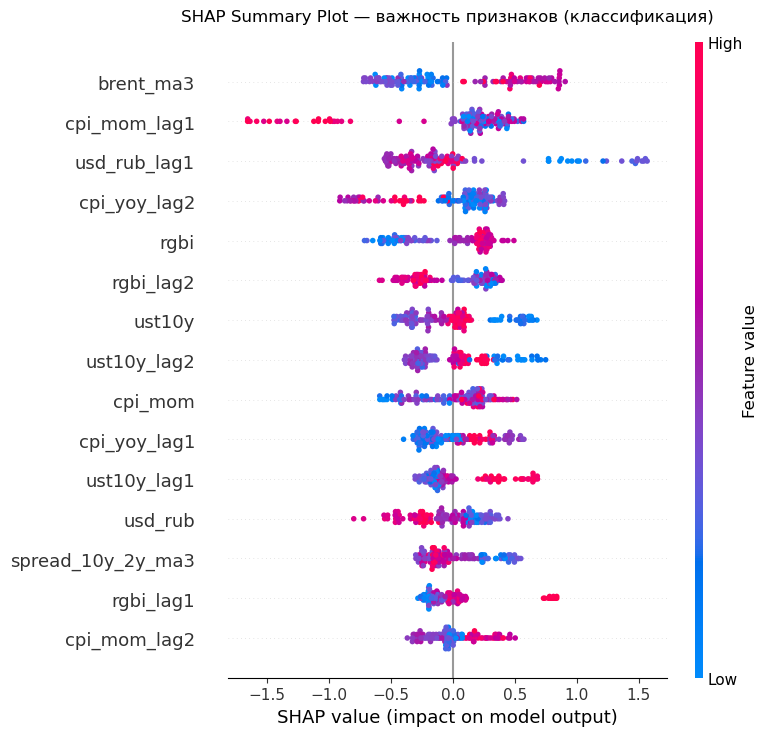

SHAP Summary Plot сохранён


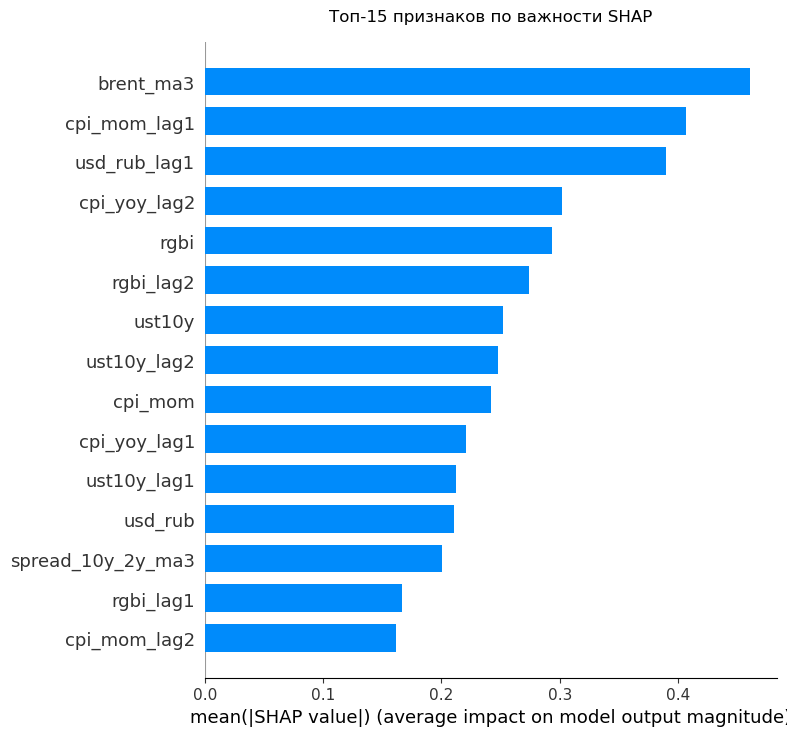

SHAP Bar Plot сохранён


In [40]:
import shap

# Обучаем финальную модель на всей выборке для SHAP
scaler_final = StandardScaler()
X2_scaled = scaler_final.fit_transform(X2)

# Модель классификации
xgb_final_cls = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_final_cls.fit(X2_scaled, y2_cls)

# Модель регрессии
xgb_final_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_final_reg.fit(X2_scaled, y2_reg)

# === SHAP анализ ===
explainer = shap.TreeExplainer(xgb_final_cls)
shap_values = explainer.shap_values(X2_scaled)

# Создаём датафрейм с именами признаков для графиков
X2_display = pd.DataFrame(X2_scaled, columns=X2.columns)

# График 1: Summary plot — глобальная важность признаков
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X2_display,
    max_display=15,
    show=False
)
plt.title('SHAP Summary Plot — важность признаков (классификация)', 
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(path + 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Summary Plot сохранён")

# График 2: Bar plot — топ признаков по средней важности
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X2_display,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Топ-15 признаков по важности SHAP', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(path + 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP Bar Plot сохранён")